# 02. Dataset Preparation

## Project
Image Processing Based Smart Supermarket Product Identification System

## Phase
Phase 2 — Dataset Preparation

## Objective
Prepare a project-specific dataset from the Retail Product Checkout (RPC)
Dataset for training and evaluating a supermarket product detection system.

## Main Tasks
1. Select a manageable subset of the RPC Dataset.
2. Map the original 200 SKU categories to 17 supermarket-level supercategories.
3. Preserve bounding-box annotations.
4. Convert COCO annotations into YOLO format.
5. Create training, validation, and testing datasets.
6. Verify class balance and annotation correctness.
7. Prepare the final dataset for YOLO model training.

## Target Classes
17 supermarket product supercategories.

## Original Dataset
Retail Product Checkout (RPC) Dataset.

## Final Model Input
YOLO-compatible images and bounding-box labels.

In [1]:
import os
import json
import zipfile
import shutil
from pathlib import Path
from collections import Counter, defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

print("Environment setup completed.")

Environment setup completed.


In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
BASE_DIR = Path("/content/drive/MyDrive/RPC_Dataset")

TRAIN_ZIP = BASE_DIR / "train2019.zip"
VAL_ZIP = BASE_DIR / "val2019.zip"
TEST_ZIP = BASE_DIR / "test2019.zip"

TRAIN_JSON = BASE_DIR / "instances_train2019.json"
VAL_JSON = BASE_DIR / "instances_val2019.json"
TEST_JSON = BASE_DIR / "instances_test2019.json"

print("Base directory:", BASE_DIR)

Base directory: /content/drive/MyDrive/RPC_Dataset


In [4]:
files_to_check = [
    TRAIN_ZIP,
    VAL_ZIP,
    TEST_ZIP,
    TRAIN_JSON,
    VAL_JSON,
    TEST_JSON
]

print("========== DATASET FILE CHECK ==========")

for file_path in files_to_check:
    print(f"{file_path.name:30} : {'FOUND' if file_path.exists() else 'MISSING'}")

========== DATASET FILE CHECK ==========
train2019.zip                  : FOUND
val2019.zip                    : FOUND
test2019.zip                   : FOUND
instances_train2019.json       : FOUND
instances_val2019.json         : FOUND
instances_test2019.json        : FOUND


## Load COCO Annotations

In [5]:
with open(TRAIN_JSON, "r") as f:
    train_data = json.load(f)

with open(VAL_JSON, "r") as f:
    val_data = json.load(f)

with open(TEST_JSON, "r") as f:
    test_data = json.load(f)

print("Train keys:", train_data.keys())
print("Validation keys:", val_data.keys())
print("Test keys:", test_data.keys())

Train keys: dict_keys(['info', 'licenses', 'categories', '__raw_Chinese_name_df', 'images', 'annotations'])
Validation keys: dict_keys(['info', 'licenses', 'categories', '__raw_Chinese_name_df', 'images', 'annotations'])
Test keys: dict_keys(['info', 'licenses', 'categories', '__raw_Chinese_name_df', 'images', 'annotations'])


In [6]:
categories_df = pd.DataFrame(train_data["categories"])

print("Original number of categories:",
      len(categories_df))

print("\nNumber of supercategories:",
      categories_df["supercategory"].nunique())

print("\nSupercategories:")
print(sorted(categories_df["supercategory"].unique()))

Original number of categories: 200

Number of supercategories: 17

Supercategories:
['alcohol', 'candy', 'canned_food', 'chocolate', 'dessert', 'dried_food', 'dried_fruit', 'drink', 'gum', 'instant_drink', 'instant_noodles', 'milk', 'personal_hygiene', 'puffed_food', 'seasoner', 'stationery', 'tissue']


## Create the 17-Class Mapping

In [7]:
supercategories = sorted(
    categories_df["supercategory"].unique()
)

supercategory_to_id = {
    name: idx
    for idx, name in enumerate(supercategories)
}

id_to_supercategory = {
    idx: name
    for name, idx in supercategory_to_id.items()
}

print("========== PROJECT CLASS MAPPING ==========")

for class_id, name in id_to_supercategory.items():
    print(f"{class_id:2d} -> {name}")

========== PROJECT CLASS MAPPING ==========
 0 -> alcohol
 1 -> candy
 2 -> canned_food
 3 -> chocolate
 4 -> dessert
 5 -> dried_food
 6 -> dried_fruit
 7 -> drink
 8 -> gum
 9 -> instant_drink
10 -> instant_noodles
11 -> milk
12 -> personal_hygiene
13 -> puffed_food
14 -> seasoner
15 -> stationery
16 -> tissue


In [8]:
categories_df["project_class_id"] = (
    categories_df["supercategory"]
    .map(supercategory_to_id)
)

display(
    categories_df[
        ["id", "name", "supercategory", "project_class_id"]
    ].head(20)
)

,id,name,supercategory,project_class_id
0,1,1_puffed_food,puffed_food,13
1,2,2_puffed_food,puffed_food,13
2,3,3_puffed_food,puffed_food,13
3,4,4_puffed_food,puffed_food,13
4,5,5_puffed_food,puffed_food,13
5,6,6_puffed_food,puffed_food,13
6,7,7_puffed_food,puffed_food,13
7,8,8_puffed_food,puffed_food,13
8,9,9_puffed_food,puffed_food,13
9,10,10_puffed_food,puffed_food,13


# 6. SKU Availability Analysis

The original RPC dataset contains 200 fine-grained SKU categories grouped
into 17 supermarket-level supercategories.

Before selecting the project dataset, the number of available training
images for each SKU is analyzed.

This analysis is used to design a balanced sampling strategy while
maintaining representation from the original dataset.

In [9]:
# Create training annotations DataFrame
train_annotations_df = pd.DataFrame(
    train_data["annotations"]
)

# Count unique training images for every original SKU
sku_image_counts = (
    train_annotations_df
    .merge(
        categories_df[["id", "name", "supercategory"]],
        left_on="category_id",
        right_on="id",
        how="left"
    )
    .groupby(
        ["supercategory", "category_id", "name"]
    )["image_id"]
    .nunique()
    .reset_index(name="image_count")
)

# Sort by supercategory and image count
sku_image_counts = sku_image_counts.sort_values(
    ["supercategory", "image_count"],
    ascending=[True, True]
)

display(sku_image_counts)

,supercategory,category_id,name,image_count
8,alcohol,94,94_alcohol,159
0,alcohol,79,79_alcohol,160
1,alcohol,80,80_alcohol,160
2,alcohol,88,88_alcohol,160
3,alcohol,89,89_alcohol,160
...,...,...,...,...
195,tissue,189,189_tissue,320
197,tissue,191,191_tissue,320
198,tissue,192,192_tissue,320
199,tissue,193,193_tissue,320


In [10]:
print("========== SKU AVAILABILITY SUMMARY ==========")

print(
    "Number of SKU categories:",
    len(sku_image_counts)
)

print(
    "Minimum images per SKU:",
    sku_image_counts["image_count"].min()
)

print(
    "Maximum images per SKU:",
    sku_image_counts["image_count"].max()
)

print(
    "Mean images per SKU:",
    round(
        sku_image_counts["image_count"].mean(),
        2
    )
)

print(
    "Median images per SKU:",
    sku_image_counts["image_count"].median()
)

========== SKU AVAILABILITY SUMMARY ==========
Number of SKU categories: 200
Minimum images per SKU: 158
Maximum images per SKU: 640
Mean images per SKU: 268.7
Median images per SKU: 320.0


In [11]:
supercategory_availability = (
    sku_image_counts
    .groupby("supercategory")["image_count"]
    .agg(
        sku_count="count",
        total_images="sum",
        min_per_sku="min",
        max_per_sku="max",
        mean_per_sku="mean"
    )
    .reset_index()
)

display(supercategory_availability)

,supercategory,sku_count,total_images,min_per_sku,max_per_sku,mean_per_sku
0,alcohol,11,1759,159,160,159.909091
1,candy,10,3040,160,320,304.000000
2,canned_food,14,2238,158,160,159.857143
3,chocolate,12,4320,320,640,360.000000
4,dessert,17,5278,160,320,310.470588
5,dried_food,9,2875,318,320,319.444444
6,dried_fruit,9,2873,315,320,319.222222
7,drink,15,2400,160,160,160.000000
8,gum,8,2240,160,320,280.000000
9,instant_drink,11,2878,160,320,261.636364


In [12]:
print("========== LOW-AVAILABILITY SKUs ==========")

low_availability = sku_image_counts[
    sku_image_counts["image_count"] < 20
]

print(
    "Number of SKUs with fewer than 20 images:",
    len(low_availability)
)

display(low_availability)

========== LOW-AVAILABILITY SKUs ==========
Number of SKUs with fewer than 20 images: 0


,supercategory,category_id,name,image_count


## Analyze Validation/Test Class Availability

# 7. Validation and Test Class Analysis

The validation and test sets contain checkout-scene images with multiple
products. Their annotations are analyzed at the project supercategory level.

The analysis will be used to select validation and testing images while
maintaining representation across the 17 project classes and the three
difficulty levels: easy, medium, and hard.

In [13]:
# Create annotation DataFrames
val_annotations_df = pd.DataFrame(
    val_data["annotations"]
)

test_annotations_df = pd.DataFrame(
    test_data["annotations"]
)

# Add project class information
val_annotations_df = val_annotations_df.merge(
    categories_df[["id", "supercategory", "project_class_id"]],
    left_on="category_id",
    right_on="id",
    how="left"
)

test_annotations_df = test_annotations_df.merge(
    categories_df[["id", "supercategory", "project_class_id"]],
    left_on="category_id",
    right_on="id",
    how="left"
)

print("Validation annotations:",
      len(val_annotations_df))

print("Test annotations:",
      len(test_annotations_df))

Validation annotations: 73602
Test annotations: 294333


In [14]:
print("========== VALIDATION CLASS DISTRIBUTION ==========")

val_class_distribution = (
    val_annotations_df["supercategory"]
    .value_counts()
    .sort_index()
)

display(val_class_distribution.to_frame("object_count"))

print("\n========== TEST CLASS DISTRIBUTION ==========")

test_class_distribution = (
    test_annotations_df["supercategory"]
    .value_counts()
    .sort_index()
)

display(test_class_distribution.to_frame("object_count"))

========== VALIDATION CLASS DISTRIBUTION ==========


,object_count
supercategory,
alcohol,3965
candy,3776
canned_food,4408
chocolate,4494
dessert,6642
dried_food,3168
dried_fruit,3408
drink,6041
gum,3087



========== TEST CLASS DISTRIBUTION ==========


,object_count
supercategory,
alcohol,15975
candy,15349
canned_food,17707
chocolate,18992
dessert,25001
dried_food,12968
dried_fruit,13996
drink,23946
gum,11658


In [16]:
# Recreate image DataFrames for this notebook

train_images_df = pd.DataFrame(train_data["images"])
val_images_df = pd.DataFrame(val_data["images"])
test_images_df = pd.DataFrame(test_data["images"])

print("========== VALIDATION DIFFICULTY ==========")

print(
    val_images_df["level"]
    .value_counts()
    .sort_index()
)

print("\n========== TEST DIFFICULTY ==========")

print(
    test_images_df["level"]
    .value_counts()
    .sort_index()
)

========== VALIDATION DIFFICULTY ==========
level
easy      2000
hard      2000
medium    2000
Name: count, dtype: int64

========== TEST DIFFICULTY ==========
level
easy      8000
hard      8000
medium    8000
Name: count, dtype: int64


In [17]:
val_annotation_analysis = (
    val_annotations_df
    .groupby(
        ["supercategory"]
    )
    .size()
    .reset_index(name="object_count")
)

display(val_annotation_analysis)

,supercategory,object_count
0,alcohol,3965
1,candy,3776
2,canned_food,4408
3,chocolate,4494
4,dessert,6642
5,dried_food,3168
6,dried_fruit,3408
7,drink,6041
8,gum,3087
9,instant_drink,3667


In [18]:
# Map each validation image to its difficulty
val_image_level = (
    val_images_df[
        ["id", "level"]
    ]
    .rename(columns={"id": "image_id"})
)

val_annotations_with_level = val_annotations_df.merge(
    val_image_level,
    on="image_id",
    how="left"
)

print("========== VALIDATION CLASS × DIFFICULTY ==========")

display(
    pd.crosstab(
        val_annotations_with_level["supercategory"],
        val_annotations_with_level["level"]
    )
)

========== VALIDATION CLASS × DIFFICULTY ==========


level,easy,hard,medium
supercategory,,,
alcohol,800,1741,1424
candy,755,1698,1323
canned_food,867,2337,1204
chocolate,973,2110,1411
dessert,1238,3072,2332
dried_food,700,1365,1103
dried_fruit,606,1613,1189
drink,1146,2756,2139
gum,601,1503,983


In [19]:
test_image_level = (
    test_images_df[
        ["id", "level"]
    ]
    .rename(columns={"id": "image_id"})
)

test_annotations_with_level = test_annotations_df.merge(
    test_image_level,
    on="image_id",
    how="left"
)

print("========== TEST CLASS × DIFFICULTY ==========")

display(
    pd.crosstab(
        test_annotations_with_level["supercategory"],
        test_annotations_with_level["level"]
    )
)

========== TEST CLASS × DIFFICULTY ==========


level,easy,hard,medium
supercategory,,,
alcohol,3353,7218,5404
candy,3239,7181,4929
canned_food,3172,8996,5539
chocolate,4101,8996,5895
dessert,4766,11510,8725
dried_food,2648,6025,4295
dried_fruit,2786,6330,4880
drink,4214,11559,8173
gum,2420,5536,3702


# 8. Dataset Selection Strategy

A project-specific subset is selected from the original RPC Dataset to
provide a manageable dataset for the 12-hour project implementation.

## Training Set

Approximately 5,000 training images will be selected.

Training images in the RPC dataset contain individual products. Images will
be sampled across the 17 project-level supercategories and distributed across
their original SKU categories where possible.

## Validation Set

1,000 validation checkout images will be selected.

The selection will preserve the original difficulty distribution:

- 333 Easy
- 333 Medium
- 334 Hard

## Test Set

1,000 test checkout images will be selected.

The selection will preserve the original difficulty distribution:

- 333 Easy
- 333 Medium
- 334 Hard

The validation and test sets contain multiple products per image and will
retain their original bounding-box annotations.

The original train, validation, and test splits will not be mixed.

## Training Selection

In [20]:
TARGET_TRAIN = 5000
NUM_CLASSES = len(supercategories)

base_per_class = TARGET_TRAIN // NUM_CLASSES
remainder = TARGET_TRAIN % NUM_CLASSES

print("Target training images:", TARGET_TRAIN)
print("Number of classes:", NUM_CLASSES)
print("Base images per class:", base_per_class)
print("Remaining images:", remainder)

Target training images: 5000
Number of classes: 17
Base images per class: 294
Remaining images: 2


## Determine the Extra Classes

In [21]:
class_capacity = (
    sku_image_counts
    .groupby("supercategory")["image_count"]
    .sum()
    .sort_values(ascending=False)
)

print("========== CLASS CAPACITY ==========")
display(class_capacity.to_frame("available_images"))

========== CLASS CAPACITY ==========


,available_images
supercategory,
tissue,6719
dessert,5278
chocolate,4320
puffed_food,3840
seasoner,3200
candy,3040
instant_noodles,3039
instant_drink,2878
dried_food,2875


In [22]:
extra_classes = list(
    class_capacity.head(remainder).index
)

print("Classes receiving one additional image:")
print(extra_classes)

Classes receiving one additional image:
['tissue', 'dessert']


## Create Training Targets

In [23]:
train_target_per_class = {
    class_name: base_per_class
    for class_name in supercategories
}

for class_name in extra_classes:
    train_target_per_class[class_name] += 1

print("========== TRAINING TARGETS ==========")

for class_name in supercategories:
    print(
        f"{class_name:20s} : "
        f"{train_target_per_class[class_name]}"
    )

print(
    "\nTotal:",
    sum(train_target_per_class.values())
)

========== TRAINING TARGETS ==========
alcohol              : 294
candy                : 294
canned_food          : 294
chocolate            : 294
dessert              : 295
dried_food           : 294
dried_fruit          : 294
drink                : 294
gum                  : 294
instant_drink        : 294
instant_noodles      : 294
milk                 : 294
personal_hygiene     : 294
puffed_food          : 294
seasoner             : 294
stationery           : 294
tissue               : 295

Total: 5000


# 8.4 SKU-Aware Training Sampling

The training subset is selected at two levels:

1. First, approximately equal numbers of images are allocated to each
   of the 17 project-level supercategories.
2. Within each supercategory, the allocated images are distributed
   across the available original SKU categories.

This prevents the training subset from being dominated by a small number
of original SKU categories.

A fixed random seed is used so that the selection can be reproduced.

In [24]:
import random

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Create a training image-level table
train_image_df = (
    train_annotations_df[
        ["image_id", "category_id"]
    ]
    .drop_duplicates("image_id")
    .merge(
        categories_df[
            ["id", "name", "supercategory", "project_class_id"]
        ],
        left_on="category_id",
        right_on="id",
        how="left"
    )
)

print("Training images available:", len(train_image_df))
print("Training classes:", train_image_df["supercategory"].nunique())

Training images available: 53739
Training classes: 17


## Sampling Function

In [25]:
def sample_sku_balanced_class(
    class_df,
    target_count,
    random_state=42
):
    """
    Select approximately balanced images across the original SKUs
    belonging to one project-level supercategory.
    """

    sku_groups = list(
        class_df.groupby("category_id")
    )

    number_of_skus = len(sku_groups)

    # Base number of images per SKU
    base_count = target_count // number_of_skus

    # Remaining images after equal allocation
    remainder = target_count % number_of_skus

    selected_parts = []

    # Sort by category ID for reproducibility
    sku_groups = sorted(
        sku_groups,
        key=lambda x: x[0]
    )

    for index, (category_id, sku_df) in enumerate(sku_groups):

        quota = base_count

        if index < remainder:
            quota += 1

        # Safety check
        quota = min(
            quota,
            len(sku_df)
        )

        sampled = sku_df.sample(
            n=quota,
            random_state=random_state + index
        )

        selected_parts.append(sampled)

    selected = pd.concat(
        selected_parts,
        ignore_index=True
    )

    # If the result is smaller than required because of a
    # capacity limitation, fill from remaining images.
    if len(selected) < target_count:

        selected_ids = set(
            selected["image_id"]
        )

        remaining = class_df[
            ~class_df["image_id"].isin(selected_ids)
        ]

        additional_needed = (
            target_count - len(selected)
        )

        additional = remaining.sample(
            n=additional_needed,
            random_state=random_state
        )

        selected = pd.concat(
            [selected, additional],
            ignore_index=True
        )

    return selected

## Select the 5,000 Training Images



In [26]:
selected_train_parts = []

for class_name in supercategories:

    class_df = train_image_df[
        train_image_df["supercategory"] == class_name
    ].copy()

    target_count = train_target_per_class[
        class_name
    ]

    selected_class = sample_sku_balanced_class(
        class_df,
        target_count,
        random_state=RANDOM_SEED
    )

    selected_train_parts.append(
        selected_class
    )

selected_train_df = pd.concat(
    selected_train_parts,
    ignore_index=True
)

print(
    "Selected training images:",
    len(selected_train_df)
)

Selected training images: 5000


## Verify Training Class Balance

In [27]:
print("========== SELECTED TRAINING DISTRIBUTION ==========")

selected_train_distribution = (
    selected_train_df["supercategory"]
    .value_counts()
    .sort_index()
)

display(
    selected_train_distribution.to_frame(
        "selected_images"
    )
)

========== SELECTED TRAINING DISTRIBUTION ==========


,selected_images
supercategory,
alcohol,294
candy,294
canned_food,294
chocolate,294
dessert,295
dried_food,294
dried_fruit,294
drink,294
gum,294


In [28]:
print(
    "Total selected:",
    selected_train_distribution.sum()
)

print(
    "Minimum class count:",
    selected_train_distribution.min()
)

print(
    "Maximum class count:",
    selected_train_distribution.max()
)

Total selected: 5000
Minimum class count: 294
Maximum class count: 295


Verify SKU Representation

In [29]:
selected_sku_distribution = (
    selected_train_df
    .groupby(
        ["supercategory", "category_id", "name"]
    )
    .size()
    .reset_index(name="selected_images")
)

display(
    selected_sku_distribution
)

,supercategory,category_id,name,selected_images
0,alcohol,79,79_alcohol,27
1,alcohol,80,80_alcohol,27
2,alcohol,88,88_alcohol,27
3,alcohol,89,89_alcohol,27
4,alcohol,90,90_alcohol,27
...,...,...,...,...
195,tissue,189,189_tissue,14
196,tissue,190,190_tissue,14
197,tissue,191,191_tissue,14
198,tissue,192,192_tissue,14


In [30]:
print("========== SKU SAMPLING SUMMARY ==========")

print(
    "Number of SKUs represented:",
    selected_sku_distribution["category_id"].nunique()
)

print(
    "Original number of SKUs:",
    len(categories_df)
)

========== SKU SAMPLING SUMMARY ==========
Number of SKUs represented: 200
Original number of SKUs: 200


# 9. Validation and Test Image Selection

The RPC validation and test datasets contain checkout-scene images with
multiple products.

A subset of 1,000 images will be selected from each split.

To preserve the original difficulty distribution, each subset will contain:

- 333 Easy images
- 333 Medium images
- 334 Hard images

The complete image and all corresponding product annotations will be
retained for every selected checkout image.

In [31]:
TARGET_VAL = 1000
TARGET_TEST = 1000

DIFFICULTY_TARGET = {
    "easy": 333,
    "medium": 333,
    "hard": 334
}

print("Validation target:", TARGET_VAL)
print("Test target:", TARGET_TEST)

print("\nDifficulty targets:")
for level, count in DIFFICULTY_TARGET.items():
    print(f"{level:8s}: {count}")

Validation target: 1000
Test target: 1000

Difficulty targets:
easy    : 333
medium  : 333
hard    : 334


In [32]:
val_selection_df = pd.DataFrame(
    val_data["images"]
)[
    ["id", "file_name", "width", "height", "level"]
].copy()

print("Validation images available:", len(val_selection_df))

display(
    val_selection_df.head()
)

Validation images available: 6000


,id,file_name,width,height,level
0,220,20180827-16-07-06-756.jpg,1850,1850,easy
1,221,20180827-16-07-10-756.jpg,1840,1840,easy
2,222,20180827-16-24-37-306.jpg,1826,1826,easy
3,223,20180827-16-24-44-306.jpg,1829,1829,easy
4,224,20180827-16-24-53-306.jpg,1826,1826,easy


In [33]:
test_selection_df = pd.DataFrame(
    test_data["images"]
)[
    ["id", "file_name", "width", "height", "level"]
].copy()

print("Test images available:", len(test_selection_df))

display(
    test_selection_df.head()
)

Test images available: 24000


,id,file_name,width,height,level
0,3,20180824-15-44-39-474.jpg,1831,1831,easy
1,4,20180824-15-44-47-474.jpg,1834,1834,easy
2,5,20180824-15-44-56-474.jpg,1839,1839,easy
3,6,20180824-15-50-57-480.jpg,1827,1827,easy
4,7,20180824-15-51-04-480.jpg,1831,1831,easy


Select validation images

In [34]:
RANDOM_SEED = 42

selected_val_parts = []

for level, target in DIFFICULTY_TARGET.items():

    level_df = val_selection_df[
        val_selection_df["level"] == level
    ].copy()

    selected = level_df.sample(
        n=target,
        random_state=RANDOM_SEED
    )

    selected_val_parts.append(selected)

selected_val_df = pd.concat(
    selected_val_parts,
    ignore_index=True
)

# Shuffle final selection
selected_val_df = selected_val_df.sample(
    frac=1,
    random_state=RANDOM_SEED
).reset_index(drop=True)

print(
    "Selected validation images:",
    len(selected_val_df)
)

Selected validation images: 1000


Verify validation difficulty

In [35]:
print("========== SELECTED VALIDATION DIFFICULTY ==========")

display(
    selected_val_df["level"]
    .value_counts()
    .sort_index()
)

========== SELECTED VALIDATION DIFFICULTY ==========


,count
level,
easy,333
hard,334
medium,333


Select test images

In [37]:
selected_test_parts = []

for level, target in DIFFICULTY_TARGET.items():

    level_df = test_selection_df[
        test_selection_df["level"] == level
    ].copy()

    selected = level_df.sample(
        n=target,
        random_state=RANDOM_SEED
    )

    selected_test_parts.append(selected)

selected_test_df = pd.concat(
    selected_test_parts,
    ignore_index=True
)

# Shuffle final selection
selected_test_df = selected_test_df.sample(
    frac=1,
    random_state=RANDOM_SEED
).reset_index(drop=True)

print(
    "Selected test images:",
    len(selected_test_df)
)

Selected test images: 1000


Verify test difficulty

In [38]:
print("========== SELECTED TEST DIFFICULTY ==========")

display(
    selected_test_df["level"]
    .value_counts()
    .sort_index()
)

========== SELECTED TEST DIFFICULTY ==========


,count
level,
easy,333
hard,334
medium,333


Verify no duplicate images

In [39]:
print("========== DUPLICATE CHECK ==========")

print(
    "Duplicate validation image IDs:",
    selected_val_df["id"].duplicated().sum()
)

print(
    "Duplicate test image IDs:",
    selected_test_df["id"].duplicated().sum()
)

========== DUPLICATE CHECK ==========
Duplicate validation image IDs: 0
Duplicate test image IDs: 0


Verify train/validation/test separation

In [40]:
train_ids = set(
    selected_train_df["image_id"]
)

val_ids = set(
    selected_val_df["id"]
)

test_ids = set(
    selected_test_df["id"]
)

print("========== SPLIT OVERLAP CHECK ==========")

print(
    "Train ∩ Validation:",
    len(train_ids & val_ids)
)

print(
    "Train ∩ Test:",
    len(train_ids & test_ids)
)

print(
    "Validation ∩ Test:",
    len(val_ids & test_ids)
)

========== SPLIT OVERLAP CHECK ==========
Train ∩ Validation: 92
Train ∩ Test: 106
Validation ∩ Test: 0


Fix the split-overlap check

In [42]:
print("========== SPLIT OVERLAP CHECK ==========")

# Build image DataFrames directly from the COCO image metadata
train_images_check = pd.DataFrame(train_data["images"])
val_images_check = pd.DataFrame(val_data["images"])
test_images_check = pd.DataFrame(test_data["images"])

# Selected validation and test filenames
selected_val_filenames = set(
    selected_val_df["file_name"]
)

selected_test_filenames = set(
    selected_test_df["file_name"]
)

# Training filenames corresponding to the selected 5,000 images
selected_train_ids = set(
    selected_train_df["image_id"]
)

selected_train_filenames = set(
    train_images_check[
        train_images_check["id"].isin(selected_train_ids)
    ]["file_name"]
)

# Check overlaps
train_val_overlap = (
    selected_train_filenames &
    selected_val_filenames
)

train_test_overlap = (
    selected_train_filenames &
    selected_test_filenames
)

val_test_overlap = (
    selected_val_filenames &
    selected_test_filenames
)

print(
    "Train ∩ Validation:",
    len(train_val_overlap)
)

print(
    "Train ∩ Test:",
    len(train_test_overlap)
)

print(
    "Validation ∩ Test:",
    len(val_test_overlap)
)

========== SPLIT OVERLAP CHECK ==========
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [43]:
print("\n========== OVERLAPPING FILENAMES ==========")

print("\nTrain / Validation:")
print(list(train_val_overlap)[:10])

print("\nTrain / Test:")
print(list(train_test_overlap)[:10])

print("\nValidation / Test:")
print(list(val_test_overlap)[:10])


========== OVERLAPPING FILENAMES ==========

Train / Validation:
[]

Train / Test:
[]

Validation / Test:
[]


Extract the selected dataset

# 10. Project Dataset Extraction

Only the selected images are extracted from the original RPC ZIP files.

The project dataset is organized into:

- train/images
- train/labels
- val/images
- val/labels
- test/images
- test/labels

The original RPC ZIP files remain unchanged.

In [44]:
PROJECT_DIR = BASE_DIR / "rpc_project_dataset"

TRAIN_IMAGES_DIR = PROJECT_DIR / "train" / "images"
TRAIN_LABELS_DIR = PROJECT_DIR / "train" / "labels"

VAL_IMAGES_DIR = PROJECT_DIR / "val" / "images"
VAL_LABELS_DIR = PROJECT_DIR / "val" / "labels"

TEST_IMAGES_DIR = PROJECT_DIR / "test" / "images"
TEST_LABELS_DIR = PROJECT_DIR / "test" / "labels"

directories = [
    TRAIN_IMAGES_DIR,
    TRAIN_LABELS_DIR,
    VAL_IMAGES_DIR,
    VAL_LABELS_DIR,
    TEST_IMAGES_DIR,
    TEST_LABELS_DIR
]

for directory in directories:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

print("========== PROJECT DIRECTORY ==========")
print(PROJECT_DIR)

for directory in directories:
    print(directory)

========== PROJECT DIRECTORY ==========
/content/drive/MyDrive/RPC_Dataset/rpc_project_dataset
/content/drive/MyDrive/RPC_Dataset/rpc_project_dataset/train/images
/content/drive/MyDrive/RPC_Dataset/rpc_project_dataset/train/labels
/content/drive/MyDrive/RPC_Dataset/rpc_project_dataset/val/images
/content/drive/MyDrive/RPC_Dataset/rpc_project_dataset/val/labels
/content/drive/MyDrive/RPC_Dataset/rpc_project_dataset/test/images
/content/drive/MyDrive/RPC_Dataset/rpc_project_dataset/test/labels


Create annotation lookup tables



In [45]:
train_annotations_lookup = defaultdict(list)
val_annotations_lookup = defaultdict(list)
test_annotations_lookup = defaultdict(list)

for annotation in train_data["annotations"]:
    train_annotations_lookup[
        annotation["image_id"]
    ].append(annotation)

for annotation in val_data["annotations"]:
    val_annotations_lookup[
        annotation["image_id"]
    ].append(annotation)

for annotation in test_data["annotations"]:
    test_annotations_lookup[
        annotation["image_id"]
    ].append(annotation)

print("Annotation lookup tables created.")

Annotation lookup tables created.


Create image metadata lookup

In [46]:
train_image_lookup = {
    image["id"]: image
    for image in train_data["images"]
}

val_image_lookup = {
    image["id"]: image
    for image in val_data["images"]
}

test_image_lookup = {
    image["id"]: image
    for image in test_data["images"]
}

print("Image lookup tables created.")

Image lookup tables created.


Create ZIP extraction function

In [47]:
def extract_selected_images(
    zip_path,
    selected_df,
    image_lookup,
    output_dir,
    zip_root
):
    """
    Extract only the selected images from an RPC ZIP file.
    """

    extracted = 0
    missing = []

    with zipfile.ZipFile(zip_path, "r") as z:

        available_files = set(z.namelist())

        for _, row in tqdm(
            selected_df.iterrows(),
            total=len(selected_df),
            desc=f"Extracting {zip_path.name}"
        ):

            image_id = row["id"]

            if image_id not in image_lookup:
                missing.append(
                    row["file_name"]
                )
                continue

            file_name = image_lookup[
                image_id
            ]["file_name"]

            zip_file_path = (
                f"{zip_root}/{file_name}"
            )

            if zip_file_path not in available_files:
                missing.append(
                    file_name
                )
                continue

            output_path = (
                output_dir / file_name
            )

            with z.open(zip_file_path) as source:
                with open(output_path, "wb") as target:
                    target.write(source.read())

            extracted += 1

    return extracted, missing

Extract validation images

In [48]:
val_extracted, val_missing = extract_selected_images(
    VAL_ZIP,
    selected_val_df,
    val_image_lookup,
    VAL_IMAGES_DIR,
    "val2019"
)

print("Validation images extracted:", val_extracted)
print("Validation images missing:", len(val_missing))

Extracting val2019.zip:   0%|          | 0/1000 [00:00<?, ?it/s]

Validation images extracted: 1000
Validation images missing: 0


Extract test images

In [49]:
test_extracted, test_missing = extract_selected_images(
    TEST_ZIP,
    selected_test_df,
    test_image_lookup,
    TEST_IMAGES_DIR,
    "test2019"
)

print("Test images extracted:", test_extracted)
print("Test images missing:", len(test_missing))

Extracting test2019.zip:   0%|          | 0/1000 [00:00<?, ?it/s]

Test images extracted: 1000
Test images missing: 0


Extract training images

In [62]:
print("========== TRAIN ZIP CHECK ==========")

print("Path:")
print(TRAIN_ZIP)

print("\nExists:")
print(TRAIN_ZIP.exists())

if TRAIN_ZIP.exists():
    print("\nFile size:")
    print(
        round(
            TRAIN_ZIP.stat().st_size / (1024**3),
            2
        ),
        "GB"
    )

========== TRAIN ZIP CHECK ==========
Path:
/content/drive/MyDrive/RPC_Dataset/train2019.zip

Exists:
True

File size:
6.78 GB


In [63]:
import zipfile

print("\n========== ZIP VALIDITY ==========")

print(
    "Is valid ZIP:",
    zipfile.is_zipfile(TRAIN_ZIP)
)


========== ZIP VALIDITY ==========
Is valid ZIP: True


In [64]:
import zipfile

print("========== ALL ZIP FILES ==========")

for name, path in [
    ("TRAIN", TRAIN_ZIP),
    ("VALIDATION", VAL_ZIP),
    ("TEST", TEST_ZIP)
]:
    print(
        f"{name:12} | "
        f"Exists: {path.exists()} | "
        f"Valid ZIP: {zipfile.is_zipfile(path)} | "
        f"Size: "
        f"{round(path.stat().st_size / (1024**3), 2) if path.exists() else 0} GB"
    )

========== ALL ZIP FILES ==========
TRAIN        | Exists: True | Valid ZIP: True | Size: 6.78 GB
VALIDATION   | Exists: True | Valid ZIP: True | Size: 1.17 GB
TEST         | Exists: True | Valid ZIP: True | Size: 4.69 GB


In [61]:
zipfile.is_zipfile(TRAIN_ZIP)

False

In [65]:
selected_train_extract_df = selected_train_df[
    ["image_id"]
].copy()

selected_train_extract_df = (
    selected_train_extract_df
    .rename(columns={"image_id": "id"})
)

selected_train_extract_df["file_name"] = (
    selected_train_extract_df["id"]
    .map(
        train_image_lookup
    )
    .apply(
        lambda x: x["file_name"]
    )
)

display(
    selected_train_extract_df.head()
)

,id,file_name
0,38809,6953029710112_camera2-32.jpg
1,38812,6953029710112_camera2-33.jpg
2,38845,6953029710112_camera3-30.jpg
3,38759,6953029710112_camera1-27.jpg
4,38798,6953029710112_camera2-23.jpg


In [66]:
train_extracted, train_missing = extract_selected_images(
    TRAIN_ZIP,
    selected_train_extract_df,
    train_image_lookup,
    TRAIN_IMAGES_DIR,
    "train2019"
)

print("Training images extracted:", train_extracted)
print("Training images missing:", len(train_missing))

Extracting train2019.zip:   0%|          | 0/5000 [00:00<?, ?it/s]

Training images extracted: 5000
Training images missing: 0


Verify the extracted dataset

In [67]:
print("========== EXTRACTED DATASET ==========")

train_image_count = len(
    list(TRAIN_IMAGES_DIR.glob("*.jpg"))
)

val_image_count = len(
    list(VAL_IMAGES_DIR.glob("*.jpg"))
)

test_image_count = len(
    list(TEST_IMAGES_DIR.glob("*.jpg"))
)

print("Train images:", train_image_count)
print("Validation images:", val_image_count)
print("Test images:", test_image_count)

print(
    "Total images:",
    train_image_count +
    val_image_count +
    test_image_count
)

========== EXTRACTED DATASET ==========
Train images: 5000
Validation images: 1000
Test images: 1000
Total images: 7000


COCO → YOLO Annotation Conversion

# 11. COCO to YOLO Annotation Conversion

The original RPC annotations use the COCO format.

Each annotation contains:

- image ID
- original category ID
- bounding box `[x, y, width, height]`

The annotations are converted to YOLO format:

`class_id x_center y_center width height`

The original 200 SKU categories are mapped to the 17 project-level
supercategories defined during dataset preparation.

In [69]:
from collections import defaultdict

train_annotations_lookup = defaultdict(list)
val_annotations_lookup = defaultdict(list)
test_annotations_lookup = defaultdict(list)

for annotation in train_data["annotations"]:
    train_annotations_lookup[
        annotation["image_id"]
    ].append(annotation)

for annotation in val_data["annotations"]:
    val_annotations_lookup[
        annotation["image_id"]
    ].append(annotation)

for annotation in test_data["annotations"]:
    test_annotations_lookup[
        annotation["image_id"]
    ].append(annotation)

print("Annotation lookup tables created.")

Annotation lookup tables created.


Create the COCO → YOLO conversion function

In [70]:
def coco_bbox_to_yolo(
    bbox,
    image_width,
    image_height
):
    """
    Convert COCO bbox:
        [x, y, width, height]

    to YOLO:
        [x_center, y_center, width, height]

    All coordinates are normalized to 0-1.
    """

    x, y, width, height = bbox

    x_center = x + (width / 2)
    y_center = y + (height / 2)

    x_center /= image_width
    y_center /= image_height
    width /= image_width
    height /= image_height

    return (
        x_center,
        y_center,
        width,
        height
    )

In [71]:
def convert_annotations_to_yolo(
    image_ids,
    image_lookup,
    annotation_lookup,
    output_label_dir
):
    """
    Convert annotations for selected images into YOLO .txt files.
    """

    converted_images = 0
    total_annotations = 0
    skipped_annotations = 0

    for image_id in tqdm(
        image_ids,
        desc="Converting annotations"
    ):

        image_info = image_lookup[image_id]

        image_width = image_info["width"]
        image_height = image_info["height"]

        annotations = annotation_lookup.get(
            image_id,
            []
        )

        label_lines = []

        for annotation in annotations:

            category_id = annotation["category_id"]

            # Find original category
            category_info = categories_df[
                categories_df["id"] == category_id
            ]

            if category_info.empty:
                skipped_annotations += 1
                continue

            # Convert original SKU → project class
            project_class_id = int(
                category_info.iloc[0]["project_class_id"]
            )

            # Convert bounding box
            x_center, y_center, width, height = (
                coco_bbox_to_yolo(
                    annotation["bbox"],
                    image_width,
                    image_height
                )
            )

            # Basic validity check
            if not (
                0 <= x_center <= 1 and
                0 <= y_center <= 1 and
                0 < width <= 1 and
                0 < height <= 1
            ):
                skipped_annotations += 1
                continue

            label_lines.append(
                f"{project_class_id} "
                f"{x_center:.6f} "
                f"{y_center:.6f} "
                f"{width:.6f} "
                f"{height:.6f}"
            )

        # Create label file
        label_file = (
            output_label_dir /
            f"{Path(image_info['file_name']).stem}.txt"
        )

        with open(label_file, "w") as f:
            f.write(
                "\n".join(label_lines)
            )

        converted_images += 1
        total_annotations += len(label_lines)

    return (
        converted_images,
        total_annotations,
        skipped_annotations
    )

In [72]:
train_ids_selected = (
    selected_train_df["image_id"]
    .tolist()
)

train_converted, train_annotations_count, train_skipped = (
    convert_annotations_to_yolo(
        train_ids_selected,
        train_image_lookup,
        train_annotations_lookup,
        TRAIN_LABELS_DIR
    )
)

print("========== TRAIN LABEL CONVERSION ==========")
print("Images converted:", train_converted)
print("Annotations converted:", train_annotations_count)
print("Annotations skipped:", train_skipped)

Converting annotations:   0%|          | 0/5000 [00:00<?, ?it/s]

========== TRAIN LABEL CONVERSION ==========
Images converted: 5000
Annotations converted: 5000
Annotations skipped: 0


Convert validation annotations

In [73]:
val_ids_selected = (
    selected_val_df["id"]
    .tolist()
)

val_converted, val_annotations_count, val_skipped = (
    convert_annotations_to_yolo(
        val_ids_selected,
        val_image_lookup,
        val_annotations_lookup,
        VAL_LABELS_DIR
    )
)

print("========== VALIDATION LABEL CONVERSION ==========")
print("Images converted:", val_converted)
print("Annotations converted:", val_annotations_count)
print("Annotations skipped:", val_skipped)

Converting annotations:   0%|          | 0/1000 [00:00<?, ?it/s]

========== VALIDATION LABEL CONVERSION ==========
Images converted: 1000
Annotations converted: 12306
Annotations skipped: 0


Convert test annotations

In [74]:
test_ids_selected = (
    selected_test_df["id"]
    .tolist()
)

test_converted, test_annotations_count, test_skipped = (
    convert_annotations_to_yolo(
        test_ids_selected,
        test_image_lookup,
        test_annotations_lookup,
        TEST_LABELS_DIR
    )
)

print("========== TEST LABEL CONVERSION ==========")
print("Images converted:", test_converted)
print("Annotations converted:", test_annotations_count)
print("Annotations skipped:", test_skipped)

Converting annotations:   0%|          | 0/1000 [00:00<?, ?it/s]

========== TEST LABEL CONVERSION ==========
Images converted: 1000
Annotations converted: 12100
Annotations skipped: 0


Verify image-label counts

In [75]:
print("=" * 60)
print("IMAGE / LABEL VERIFICATION")
print("=" * 60)

train_images = len(
    list(TRAIN_IMAGES_DIR.glob("*.jpg"))
)
train_labels = len(
    list(TRAIN_LABELS_DIR.glob("*.txt"))
)

val_images = len(
    list(VAL_IMAGES_DIR.glob("*.jpg"))
)
val_labels = len(
    list(VAL_LABELS_DIR.glob("*.txt"))
)

test_images = len(
    list(TEST_IMAGES_DIR.glob("*.jpg"))
)
test_labels = len(
    list(TEST_LABELS_DIR.glob("*.txt"))
)

print(f"Train      : {train_images} images | {train_labels} labels")
print(f"Validation : {val_images} images | {val_labels} labels")
print(f"Test       : {test_images} images | {test_labels} labels")

IMAGE / LABEL VERIFICATION
Train      : 5000 images | 5000 labels
Validation : 1000 images | 1000 labels
Test       : 1000 images | 1000 labels


# 12. YOLO Annotation Quality Validation

The generated YOLO annotations are validated before model training.

The validation checks ensure that:
- every image has a corresponding label file,
- label files contain valid annotations,
- class IDs belong to the 17 project classes,
- normalized bounding-box coordinates are within valid ranges,
- annotations can be visualized correctly.

In [76]:
def find_empty_labels(label_dir):
    empty_files = []

    for label_file in label_dir.glob("*.txt"):
        if label_file.stat().st_size == 0:
            empty_files.append(label_file.name)

    return empty_files


train_empty = find_empty_labels(TRAIN_LABELS_DIR)
val_empty = find_empty_labels(VAL_LABELS_DIR)
test_empty = find_empty_labels(TEST_LABELS_DIR)

print("========== EMPTY LABEL CHECK ==========")

print("Train empty labels:", len(train_empty))
print("Validation empty labels:", len(val_empty))
print("Test empty labels:", len(test_empty))

========== EMPTY LABEL CHECK ==========
Train empty labels: 0
Validation empty labels: 0
Test empty labels: 0


Validate class IDs and coordinates

In [77]:
NUM_CLASSES = 17

def validate_yolo_labels(label_dir, num_classes):
    invalid_class = []
    invalid_values = []
    total_annotations = 0

    for label_file in label_dir.glob("*.txt"):

        with open(label_file, "r") as f:
            lines = [
                line.strip()
                for line in f
                if line.strip()
            ]

        for line_number, line in enumerate(lines, start=1):

            parts = line.split()

            if len(parts) != 5:
                invalid_values.append(
                    (label_file.name, line_number, line)
                )
                continue

            try:
                class_id = int(parts[0])

                values = [
                    float(x)
                    for x in parts[1:]
                ]

            except ValueError:
                invalid_values.append(
                    (label_file.name, line_number, line)
                )
                continue

            x_center, y_center, width, height = values

            total_annotations += 1

            if not (0 <= class_id < num_classes):
                invalid_class.append(
                    (label_file.name, class_id)
                )

            if not (
                0 <= x_center <= 1 and
                0 <= y_center <= 1 and
                0 < width <= 1 and
                0 < height <= 1
            ):
                invalid_values.append(
                    (label_file.name, line_number, line)
                )

    return (
        total_annotations,
        invalid_class,
        invalid_values
    )

In [78]:
train_total, train_bad_classes, train_bad_values = (
    validate_yolo_labels(
        TRAIN_LABELS_DIR,
        NUM_CLASSES
    )
)

val_total, val_bad_classes, val_bad_values = (
    validate_yolo_labels(
        VAL_LABELS_DIR,
        NUM_CLASSES
    )
)

test_total, test_bad_classes, test_bad_values = (
    validate_yolo_labels(
        TEST_LABELS_DIR,
        NUM_CLASSES
    )
)

print("========== YOLO LABEL VALIDATION ==========")

print("\nTRAIN")
print("Annotations:", train_total)
print("Invalid class IDs:", len(train_bad_classes))
print("Invalid coordinates:", len(train_bad_values))

print("\nVALIDATION")
print("Annotations:", val_total)
print("Invalid class IDs:", len(val_bad_classes))
print("Invalid coordinates:", len(val_bad_values))

print("\nTEST")
print("Annotations:", test_total)
print("Invalid class IDs:", len(test_bad_classes))
print("Invalid coordinates:", len(test_bad_values))

========== YOLO LABEL VALIDATION ==========

TRAIN
Annotations: 5000
Invalid class IDs: 0
Invalid coordinates: 0

VALIDATION
Annotations: 12306
Invalid class IDs: 0
Invalid coordinates: 0

TEST
Annotations: 12100
Invalid class IDs: 0
Invalid coordinates: 0


Analyze the final project class distribution

In [79]:
class_names = {
    0: "alcohol",
    1: "candy",
    2: "canned_food",
    3: "chocolate",
    4: "dessert",
    5: "dried_food",
    6: "dried_fruit",
    7: "drink",
    8: "gum",
    9: "instant_drink",
    10: "instant_noodles",
    11: "milk",
    12: "personal_hygiene",
    13: "puffed_food",
    14: "seasoner",
    15: "stationery",
    16: "tissue"
}

In [80]:
def count_yolo_classes(label_dir):
    counts = Counter()

    for label_file in label_dir.glob("*.txt"):

        with open(label_file, "r") as f:

            for line in f:

                line = line.strip()

                if not line:
                    continue

                class_id = int(
                    line.split()[0]
                )

                counts[class_id] += 1

    return counts


train_class_counts = count_yolo_classes(
    TRAIN_LABELS_DIR
)

val_class_counts = count_yolo_classes(
    VAL_LABELS_DIR
)

test_class_counts = count_yolo_classes(
    TEST_LABELS_DIR
)

In [81]:
class_distribution_df = pd.DataFrame({
    "class_id": range(NUM_CLASSES),
    "class_name": [
        class_names[i]
        for i in range(NUM_CLASSES)
    ],
    "train_objects": [
        train_class_counts[i]
        for i in range(NUM_CLASSES)
    ],
    "val_objects": [
        val_class_counts[i]
        for i in range(NUM_CLASSES)
    ],
    "test_objects": [
        test_class_counts[i]
        for i in range(NUM_CLASSES)
    ]
})

display(class_distribution_df)

,class_id,class_name,train_objects,val_objects,test_objects
0,0,alcohol,294,651,672
1,1,candy,294,566,625
2,2,canned_food,294,757,713
3,3,chocolate,294,726,713
4,4,dessert,295,1134,1010
5,5,dried_food,294,535,529
6,6,dried_fruit,294,570,635
7,7,drink,294,989,1055
8,8,gum,294,551,522
9,9,instant_drink,294,633,585


Check whether any class is missing

In [82]:
print("========== MISSING CLASS CHECK ==========")

for split_name, counts in [
    ("Train", train_class_counts),
    ("Validation", val_class_counts),
    ("Test", test_class_counts)
]:

    missing = [
        class_names[i]
        for i in range(NUM_CLASSES)
        if counts[i] == 0
    ]

    print(f"{split_name}: {missing}")

========== MISSING CLASS CHECK ==========
Train: []
Validation: []
Test: []


Visualize a converted training annotation

In [83]:
import random
from PIL import Image
import matplotlib.pyplot as plt

In [84]:
sample_image_path = random.choice(
    list(TRAIN_IMAGES_DIR.glob("*.jpg"))
)

sample_label_path = (
    TRAIN_LABELS_DIR /
    f"{sample_image_path.stem}.txt"
)

print("Image:", sample_image_path.name)
print("Label:", sample_label_path.name)

Image: 6914973604056_camera3-18.jpg
Label: 6914973604056_camera3-18.txt


In [85]:
image = Image.open(
    sample_image_path
).convert("RGB")

image_width, image_height = image.size

print(
    "Image size:",
    image_width,
    "x",
    image_height
)

Image size: 2592 x 1944


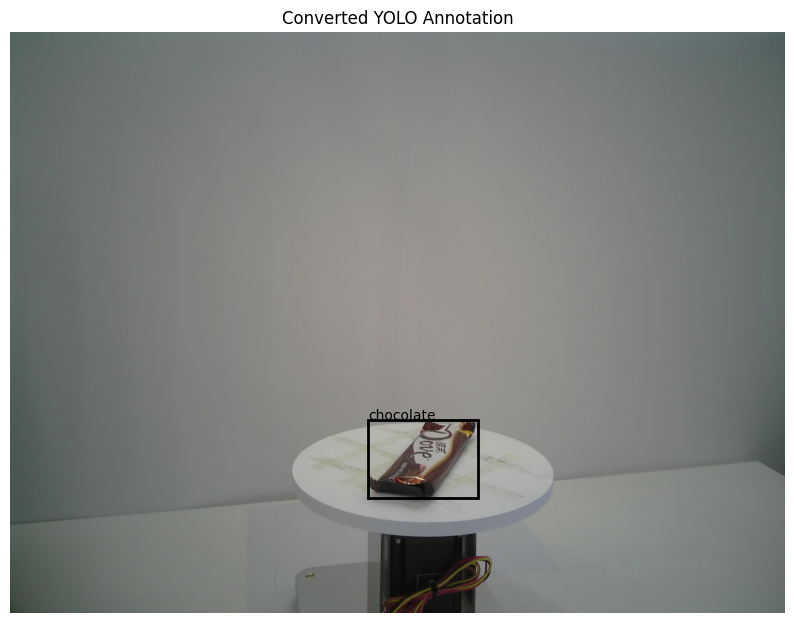

In [86]:
fig, ax = plt.subplots(
    figsize=(10, 10)
)

ax.imshow(image)

with open(sample_label_path, "r") as f:

    for line in f:

        parts = line.strip().split()

        if len(parts) != 5:
            continue

        class_id = int(parts[0])

        x_center = float(parts[1])
        y_center = float(parts[2])
        width = float(parts[3])
        height = float(parts[4])

        # Convert normalized YOLO coordinates
        # back to pixel coordinates
        box_width = width * image_width
        box_height = height * image_height

        x_center_pixel = x_center * image_width
        y_center_pixel = y_center * image_height

        x = (
            x_center_pixel -
            box_width / 2
        )

        y = (
            y_center_pixel -
            box_height / 2
        )

        rectangle = plt.Rectangle(
            (x, y),
            box_width,
            box_height,
            fill=False,
            linewidth=2
        )

        ax.add_patch(rectangle)

        ax.text(
            x,
            y,
            class_names[class_id],
            fontsize=10
        )

ax.axis("off")
ax.set_title(
    "Converted YOLO Annotation"
)

plt.show()

Create data.yaml

# 13. YOLO Dataset Configuration

The prepared dataset contains 17 project-level supermarket product
categories.

The `data.yaml` file defines the dataset paths and class names required
for YOLO training.

In [87]:
class_names_list = [
    class_names[i]
    for i in range(NUM_CLASSES)
]

print("========== YOLO CLASS NAMES ==========")

for i, name in enumerate(class_names_list):
    print(f"{i}: {name}")

========== YOLO CLASS NAMES ==========
0: alcohol
1: candy
2: canned_food
3: chocolate
4: dessert
5: dried_food
6: dried_fruit
7: drink
8: gum
9: instant_drink
10: instant_noodles
11: milk
12: personal_hygiene
13: puffed_food
14: seasoner
15: stationery
16: tissue


In [88]:
import yaml

data_yaml = {
    "path": str(PROJECT_DIR),

    "train": "train/images",
    "val": "val/images",
    "test": "test/images",

    "nc": NUM_CLASSES,

    "names": class_names_list
}

DATA_YAML_PATH = PROJECT_DIR / "data.yaml"

with open(DATA_YAML_PATH, "w") as f:
    yaml.safe_dump(
        data_yaml,
        f,
        sort_keys=False
    )

print("data.yaml created:")
print(DATA_YAML_PATH)

data.yaml created:
/content/drive/MyDrive/RPC_Dataset/rpc_project_dataset/data.yaml


Display the YAML

In [89]:
print("========== data.yaml ==========\n")

with open(DATA_YAML_PATH, "r") as f:
    print(f.read())

========== data.yaml ==========

path: /content/drive/MyDrive/RPC_Dataset/rpc_project_dataset
train: train/images
val: val/images
test: test/images
nc: 17
names:
- alcohol
- candy
- canned_food
- chocolate
- dessert
- dried_food
- dried_fruit
- drink
- gum
- instant_drink
- instant_noodles
- milk
- personal_hygiene
- puffed_food
- seasoner
- stationery
- tissue



Final Dataset Verification

In [90]:
print("========== FINAL DATASET STRUCTURE ==========")

for split in ["train", "val", "test"]:

    images_dir = PROJECT_DIR / split / "images"
    labels_dir = PROJECT_DIR / split / "labels"

    print(f"\n{split.upper()}")
    print("Images :", len(list(images_dir.glob("*.jpg"))))
    print("Labels :", len(list(labels_dir.glob("*.txt"))))

========== FINAL DATASET STRUCTURE ==========

TRAIN
Images : 5000
Labels : 5000

VAL
Images : 1000
Labels : 1000

TEST
Images : 1000
Labels : 1000


Check image-label matching

In [91]:
def check_image_label_matching(
    images_dir,
    labels_dir
):
    image_stems = {
        p.stem
        for p in images_dir.glob("*.jpg")
    }

    label_stems = {
        p.stem
        for p in labels_dir.glob("*.txt")
    }

    missing_labels = image_stems - label_stems
    orphan_labels = label_stems - image_stems

    return missing_labels, orphan_labels


for split in ["train", "val", "test"]:

    images_dir = PROJECT_DIR / split / "images"
    labels_dir = PROJECT_DIR / split / "labels"

    missing, orphan = check_image_label_matching(
        images_dir,
        labels_dir
    )

    print(f"\n{split.upper()}")
    print("Images without labels:", len(missing))
    print("Labels without images:", len(orphan))


TRAIN
Images without labels: 0
Labels without images: 0

VAL
Images without labels: 0
Labels without images: 0

TEST
Images without labels: 0
Labels without images: 0


Save Dataset Summary

In [92]:
dataset_summary = {
    "total_images": 7000,
    "train_images": 5000,
    "validation_images": 1000,
    "test_images": 1000,
    "original_classes": 200,
    "project_classes": 17,
    "model_format": "YOLO",
    "annotation_format_original": "COCO",
    "annotation_format_final": "YOLO"
}

summary_df = pd.DataFrame(
    dataset_summary.items(),
    columns=["Property", "Value"]
)

display(summary_df)

,Property,Value
0,total_images,7000
1,train_images,5000
2,validation_images,1000
3,test_images,1000
4,original_classes,200
5,project_classes,17
6,model_format,YOLO
7,annotation_format_original,COCO
8,annotation_format_final,YOLO


# Phase 2 Conclusion

The RPC Dataset has been successfully prepared for the Smart Supermarket
Product Identification System.

The original dataset containing 200 fine-grained SKU categories was mapped
to 17 supermarket-level product categories.

A project-specific dataset containing 7,000 images was created:

- 5,000 training images
- 1,000 validation images
- 1,000 testing images

The original COCO bounding-box annotations were converted into YOLO format.
The resulting annotations were validated for class IDs, normalized bounding
box coordinates, image-label matching, and class representation.

The validation and test sets preserve the original Easy, Medium, and Hard
checkout-scene categories.

The dataset is now organized in YOLO format and is ready for model training.